In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files
uploaded = files.upload()
w=pd.read_csv('winequality-red.csv')
w.head()

Saving winequality-red.csv to winequality-red.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
w.describe()
w.shape
w.info()
w.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


<Axes: >

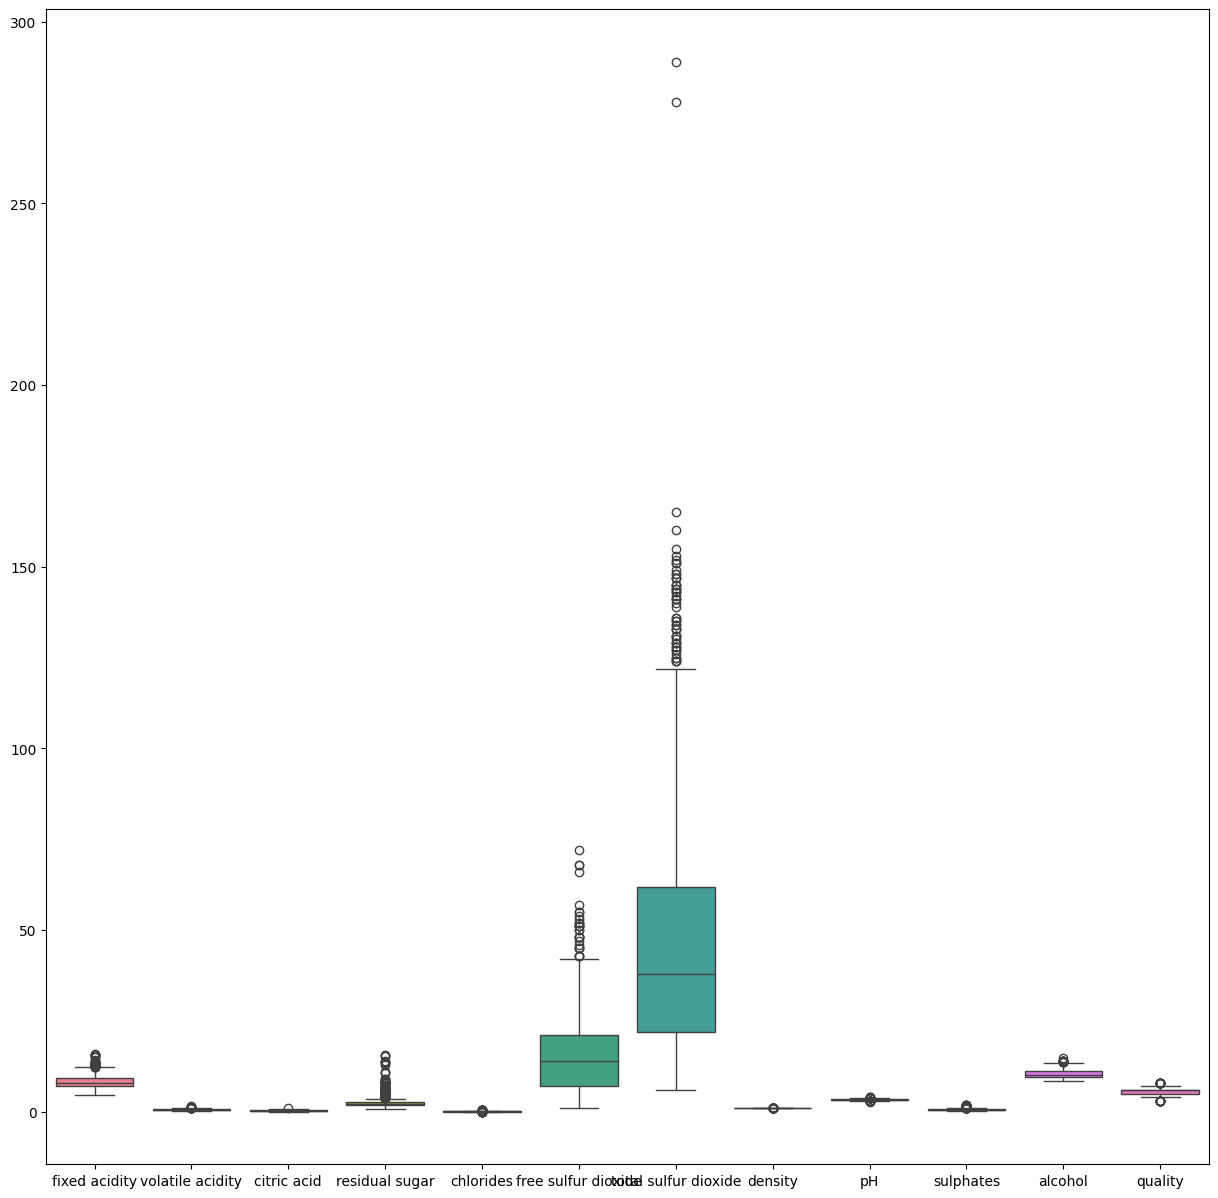

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=w,ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='fixed acidity'>

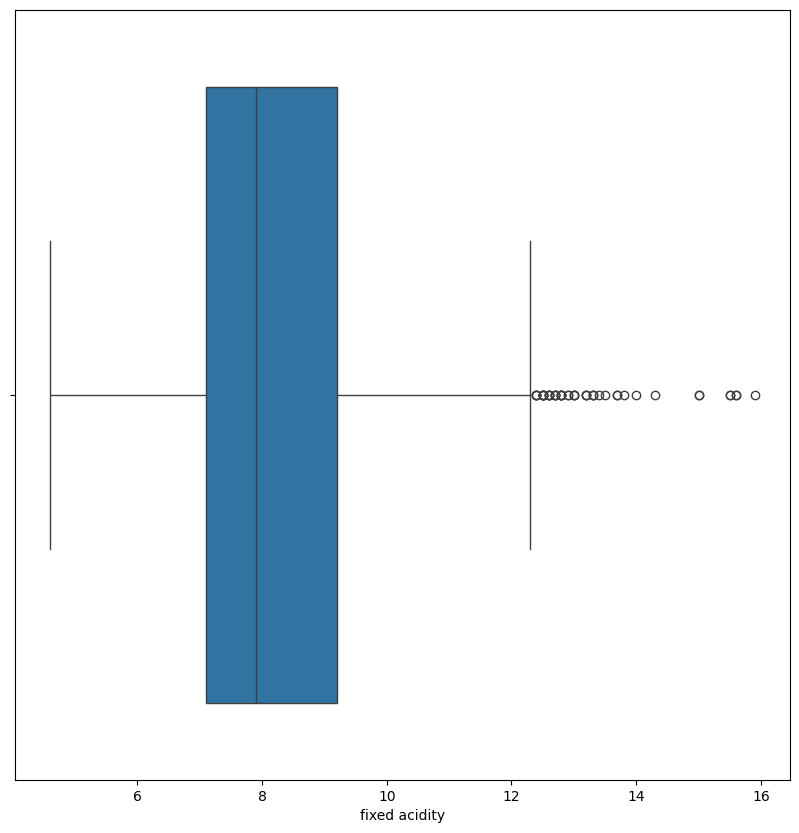

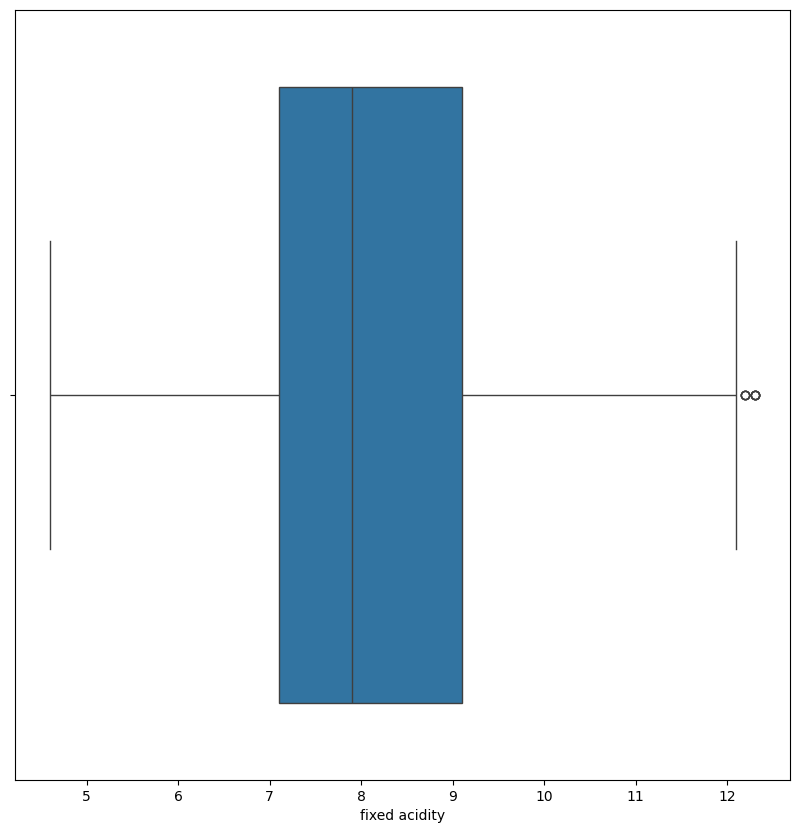

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=w['fixed acidity'],ax=ax)
q1=w['fixed acidity'].quantile(0.25)
q3=w['fixed acidity'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data=w[(w['fixed acidity']>lower_bound)&(w['fixed acidity']<upper_bound)]
print(new_data)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data['fixed acidity'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='volatile acidity'>

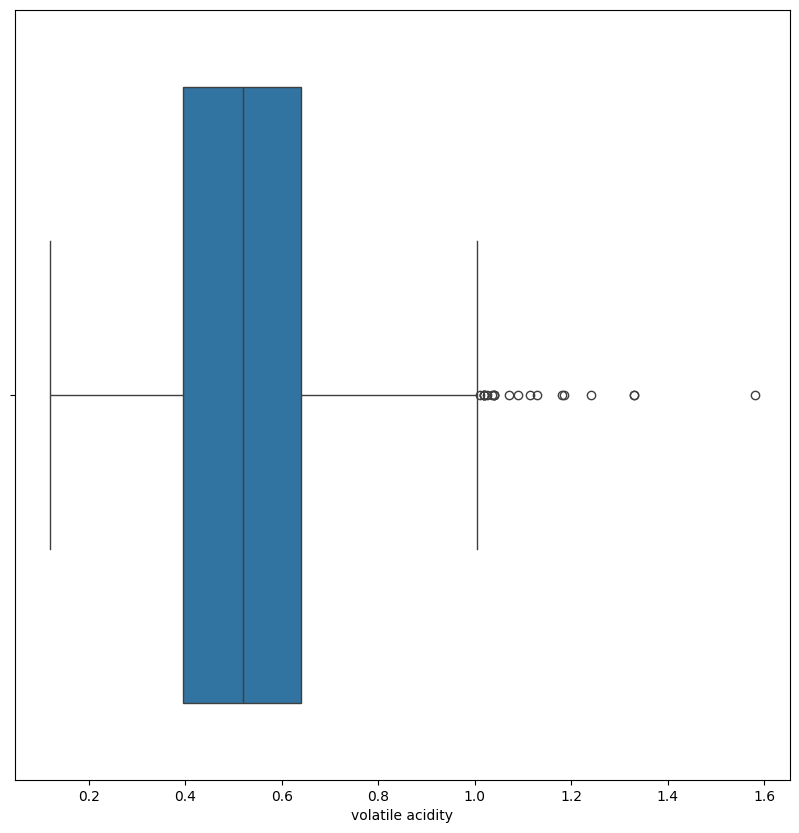

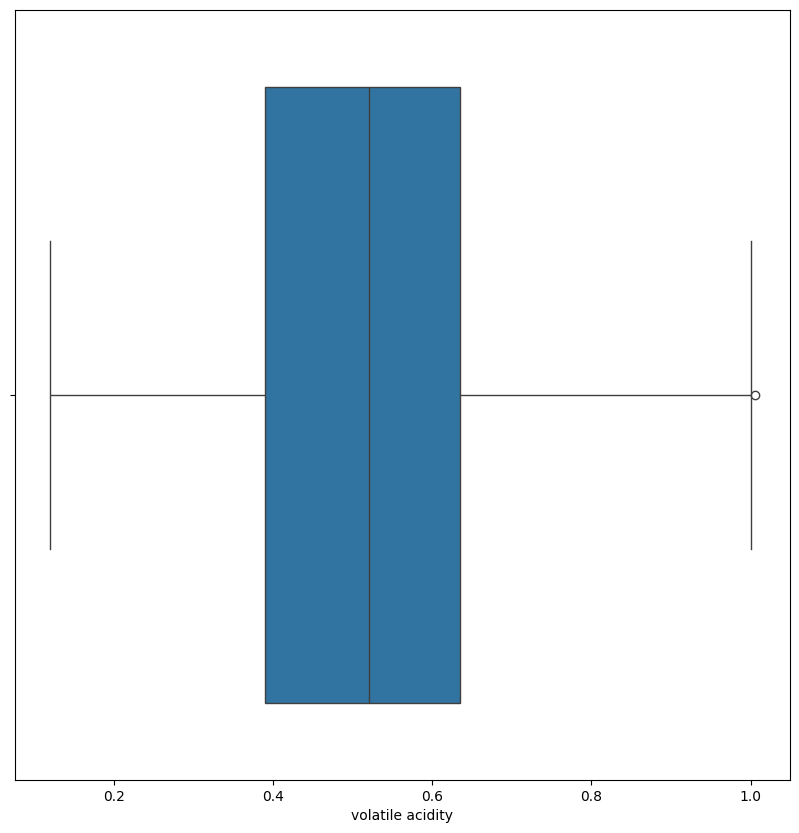

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data['volatile acidity'],ax=ax)
q1=new_data['volatile acidity'].quantile(0.25)
q3=new_data['volatile acidity'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data1=new_data[(new_data['volatile acidity']>lower_bound)&(new_data['volatile acidity']<upper_bound)]
print(new_data1)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data1['volatile acidity'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='citric acid'>

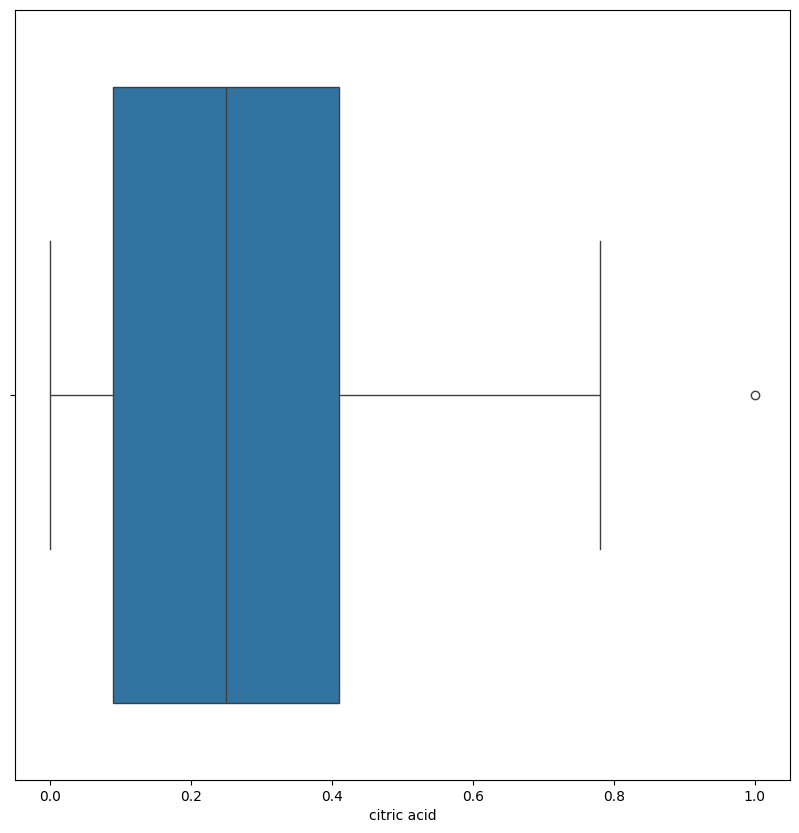

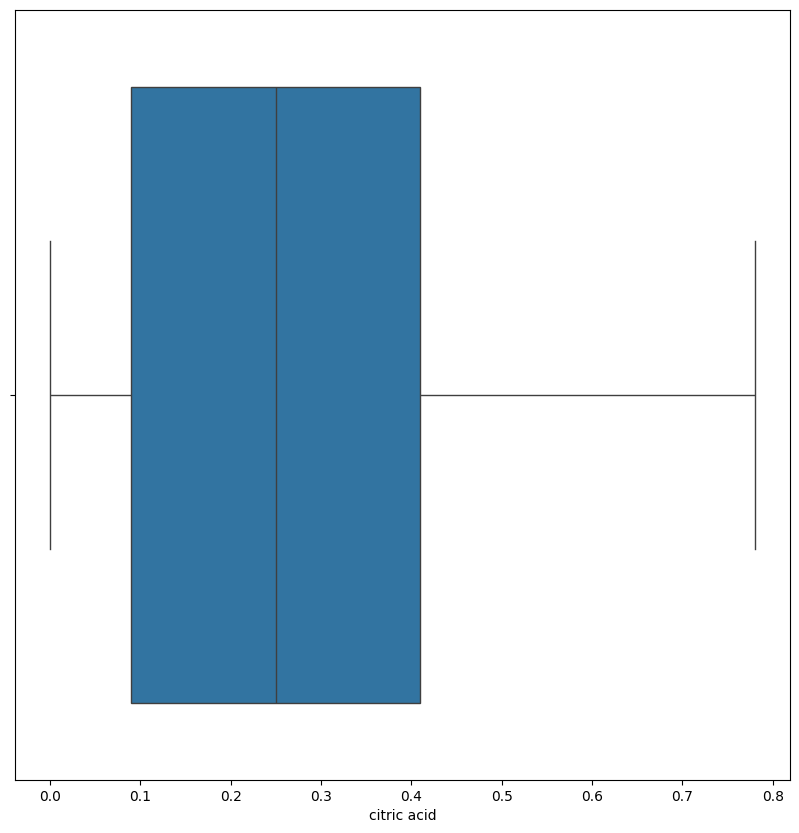

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data1['citric acid'],ax=ax)
q1=new_data1['citric acid'].quantile(0.25)
q3=new_data1['citric acid'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data2=new_data1[(new_data1['citric acid']>lower_bound)&(new_data1['citric acid']<upper_bound)]
print(new_data2)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data2['citric acid'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='residual sugar'>

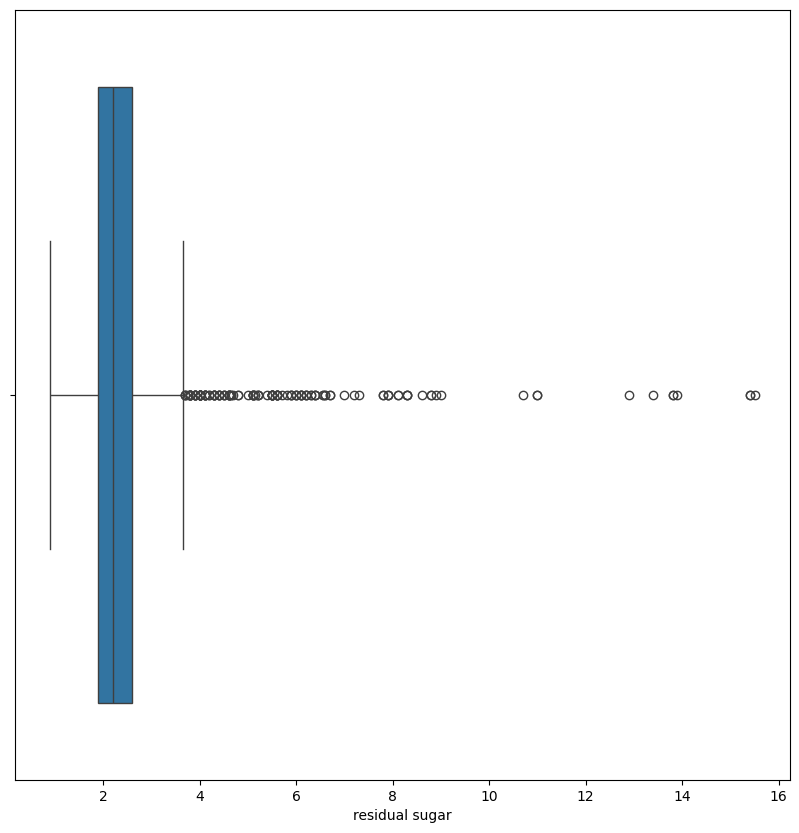

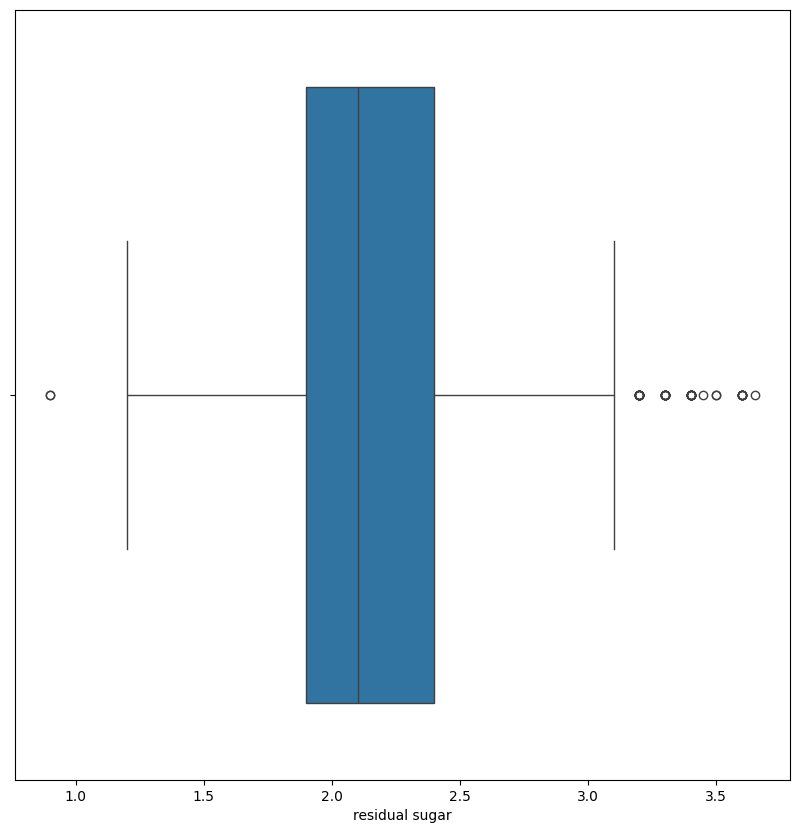

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data2['residual sugar'],ax=ax)
q1=new_data2['residual sugar'].quantile(0.25)
q3=new_data2['residual sugar'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data3=new_data2[(new_data2['residual sugar']>lower_bound)&(new_data2['residual sugar']<upper_bound)]
print(new_data3)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data3['residual sugar'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='chlorides'>

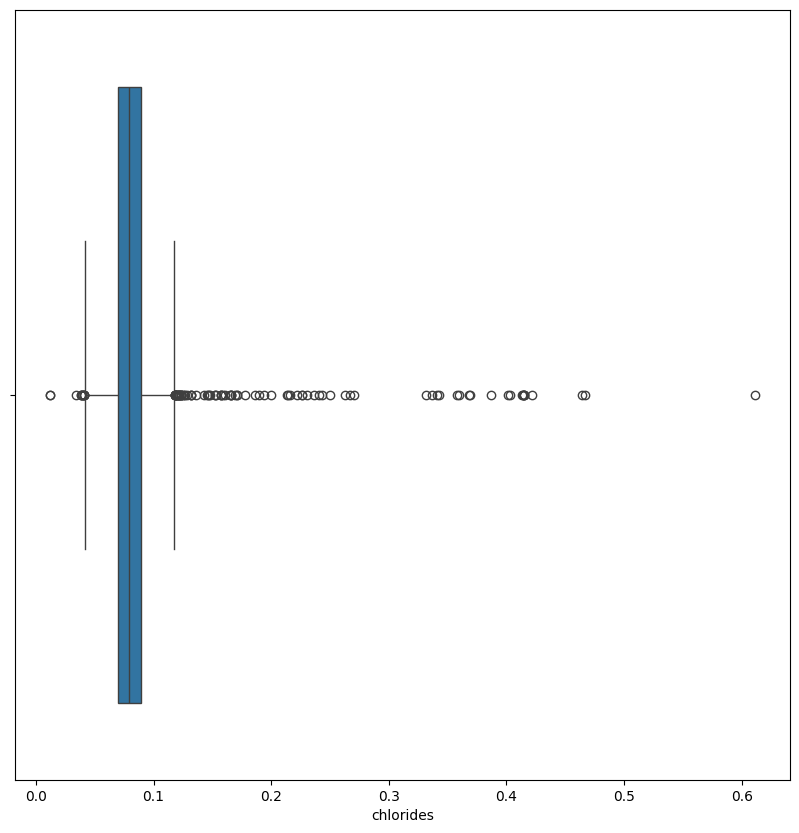

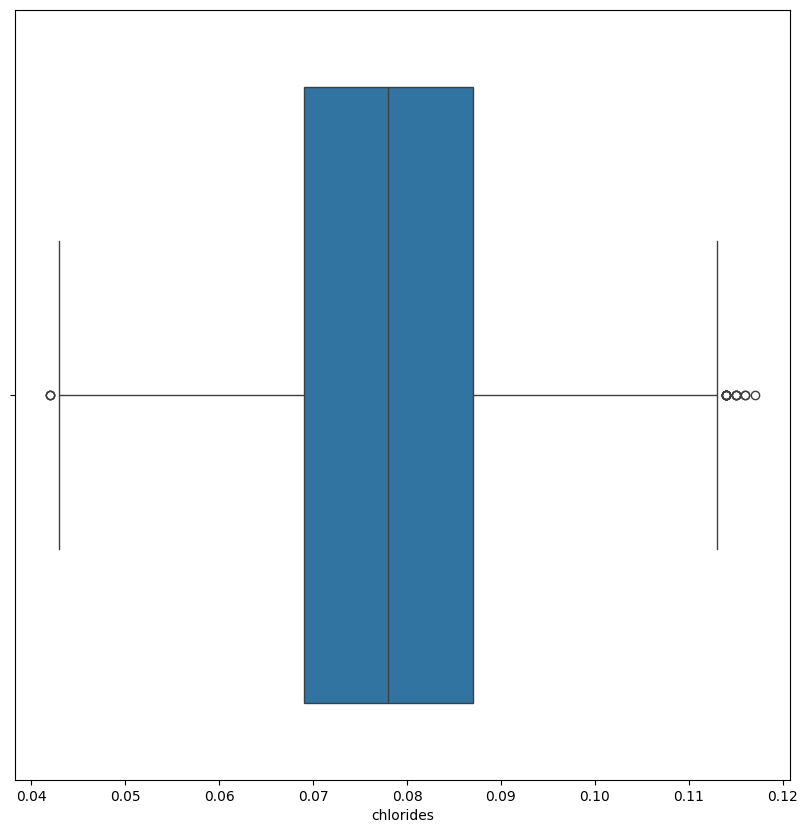

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data3['chlorides'],ax=ax)
q1=new_data3['chlorides'].quantile(0.25)
q3=new_data3['chlorides'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data4=new_data3[(new_data3['chlorides']>lower_bound)&(new_data3['chlorides']<upper_bound)]
print(new_data4)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data4['chlorides'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='free sulfur dioxide'>

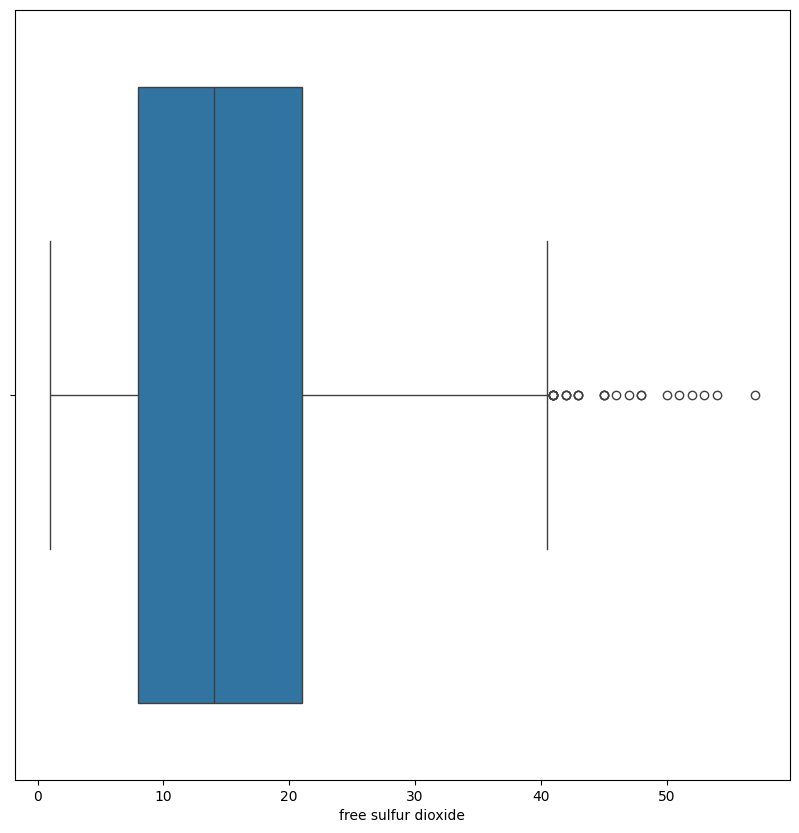

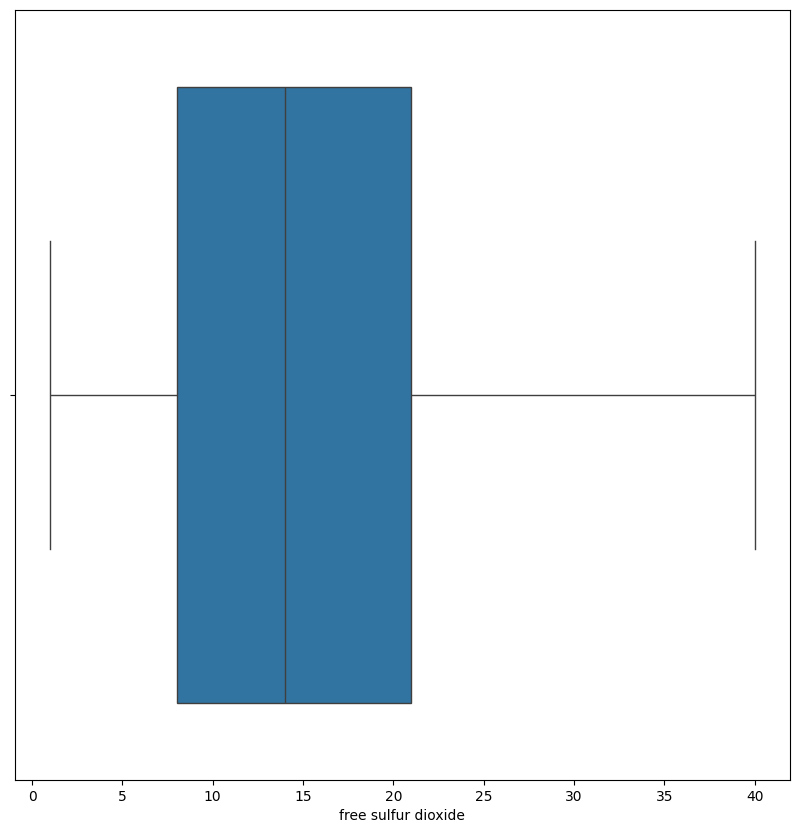

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data4['free sulfur dioxide'],ax=ax)
q1=new_data4['free sulfur dioxide'].quantile(0.25)
q3=new_data4['free sulfur dioxide'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data5=new_data4[(new_data4['free sulfur dioxide']>lower_bound)&(new_data4['free sulfur dioxide']<upper_bound)]
print(new_data5)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data5['free sulfur dioxide'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='total sulfur dioxide'>

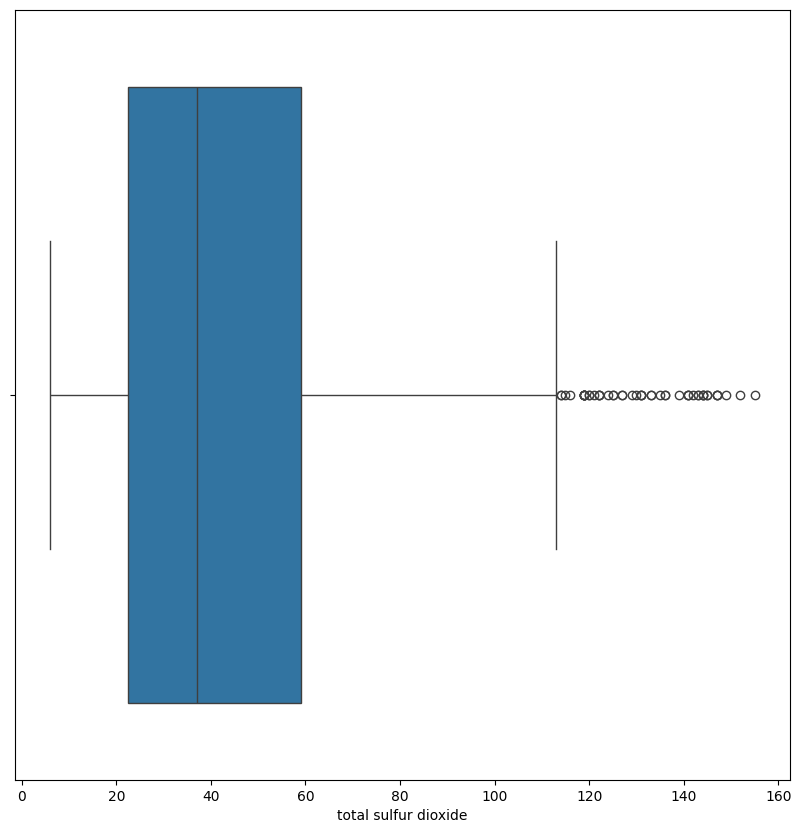

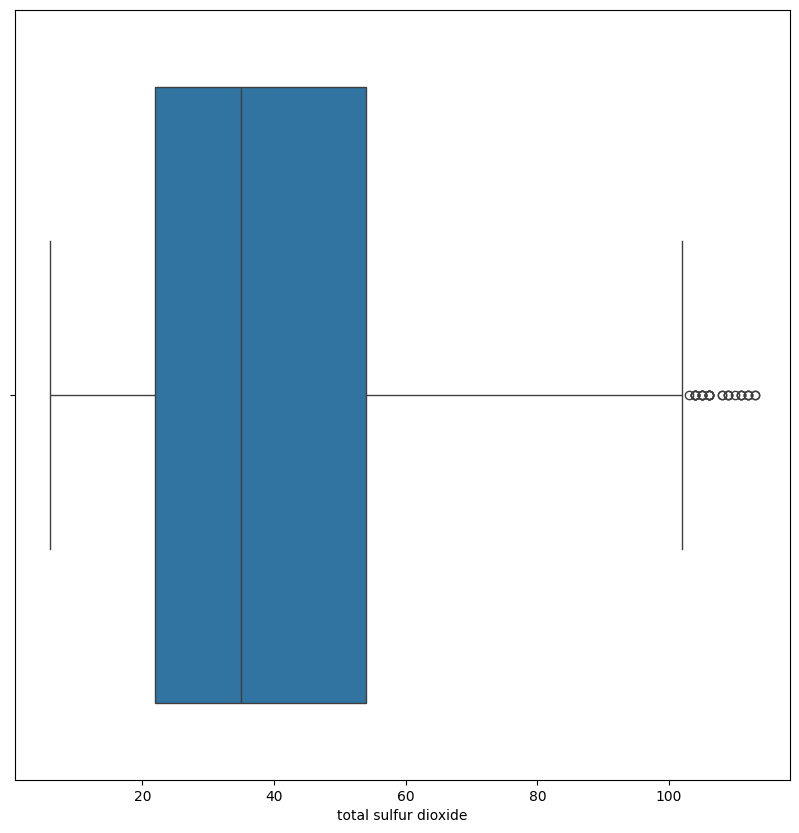

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data5['total sulfur dioxide'],ax=ax)
q1=new_data5['total sulfur dioxide'].quantile(0.25)
q3=new_data5['total sulfur dioxide'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data6=new_data5[(new_data5['total sulfur dioxide']>lower_bound)&(new_data5['total sulfur dioxide']<upper_bound)]
print(new_data6)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data6['total sulfur dioxide'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='density'>

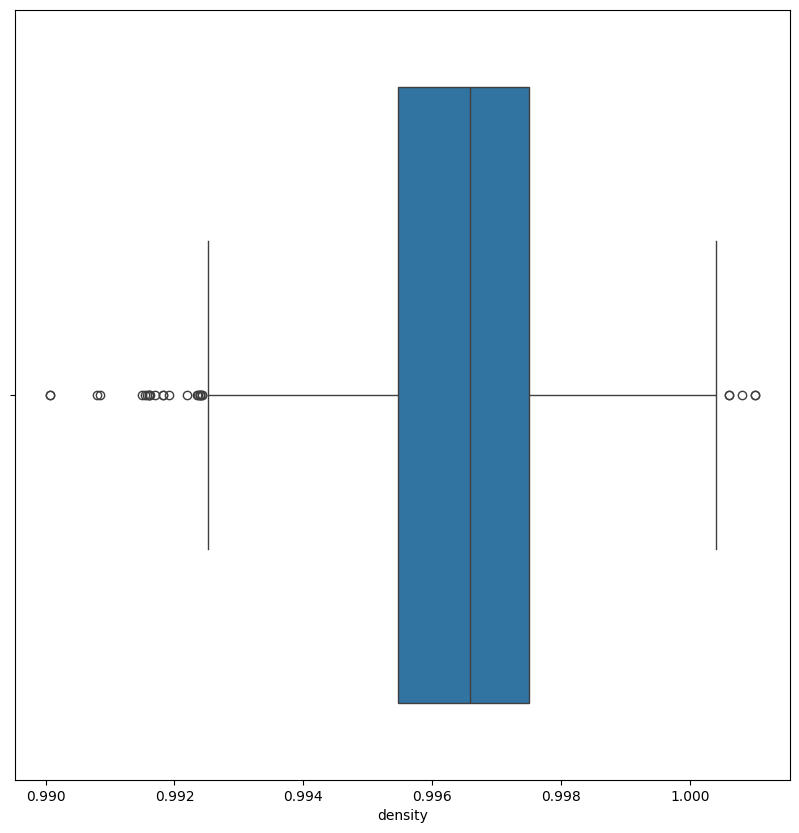

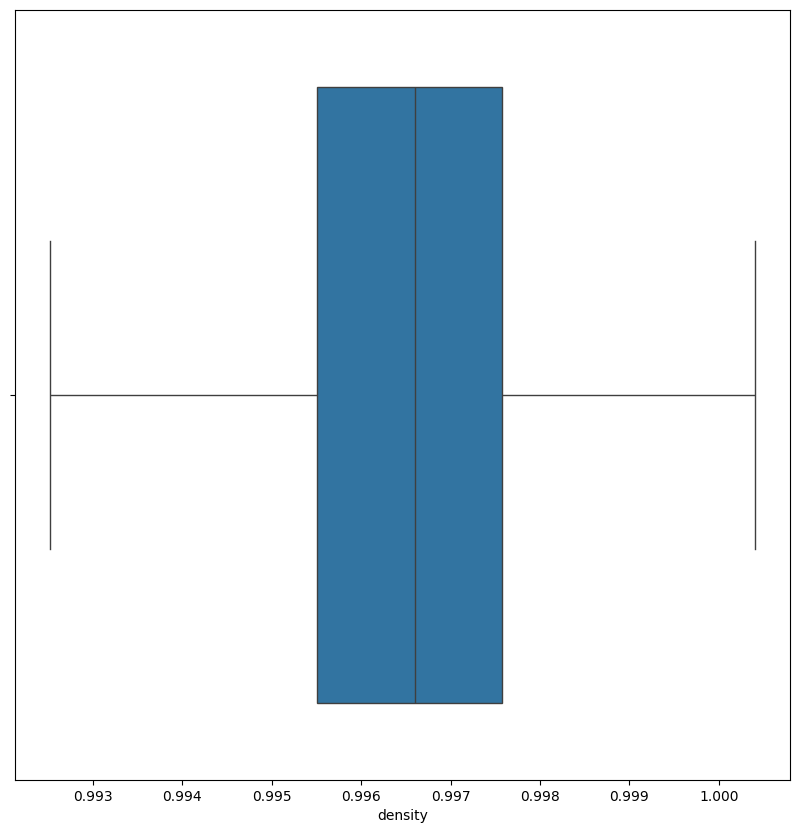

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data6['density'],ax=ax)
q1=new_data6['density'].quantile(0.25)
q3=new_data6['density'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data7=new_data6[(new_data6['density']>lower_bound)&(new_data6['density']<upper_bound)]
print(new_data7)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data7['density'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='pH'>

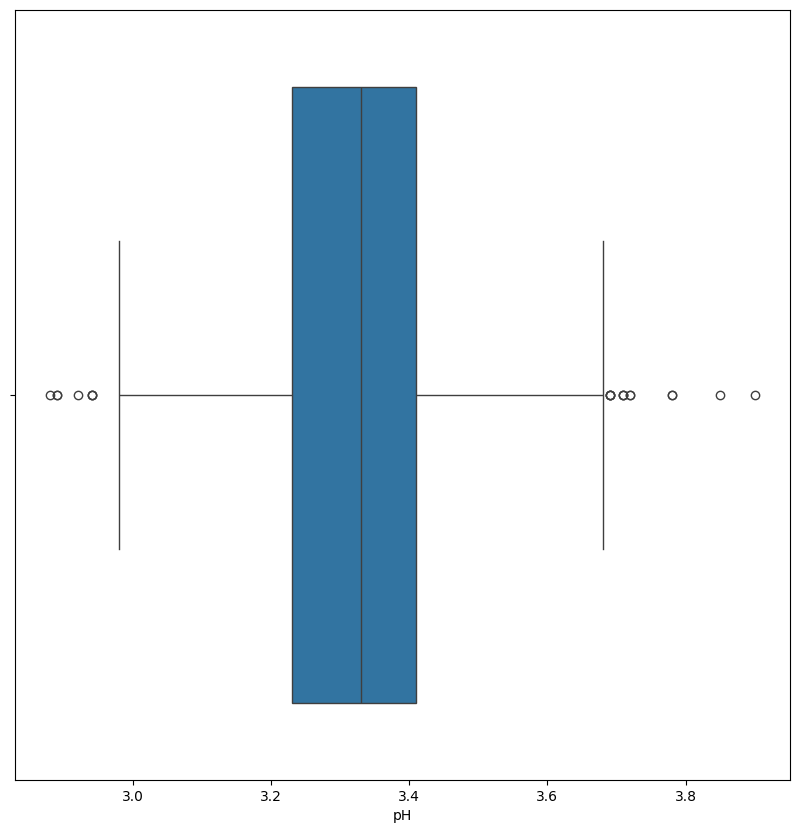

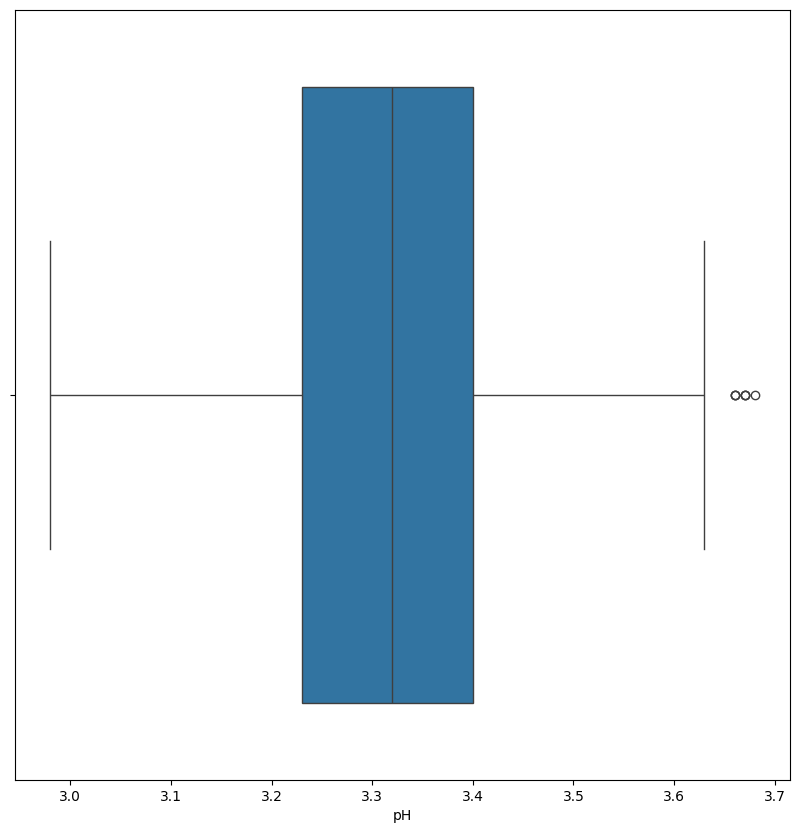

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data7['pH'],ax=ax)
q1=new_data7['pH'].quantile(0.25)
q3=new_data7['pH'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data8=new_data7[(new_data7['pH']>lower_bound)&(new_data7['pH']<upper_bound)]
print(new_data8)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data8['pH'],ax=ax)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='sulphates'>

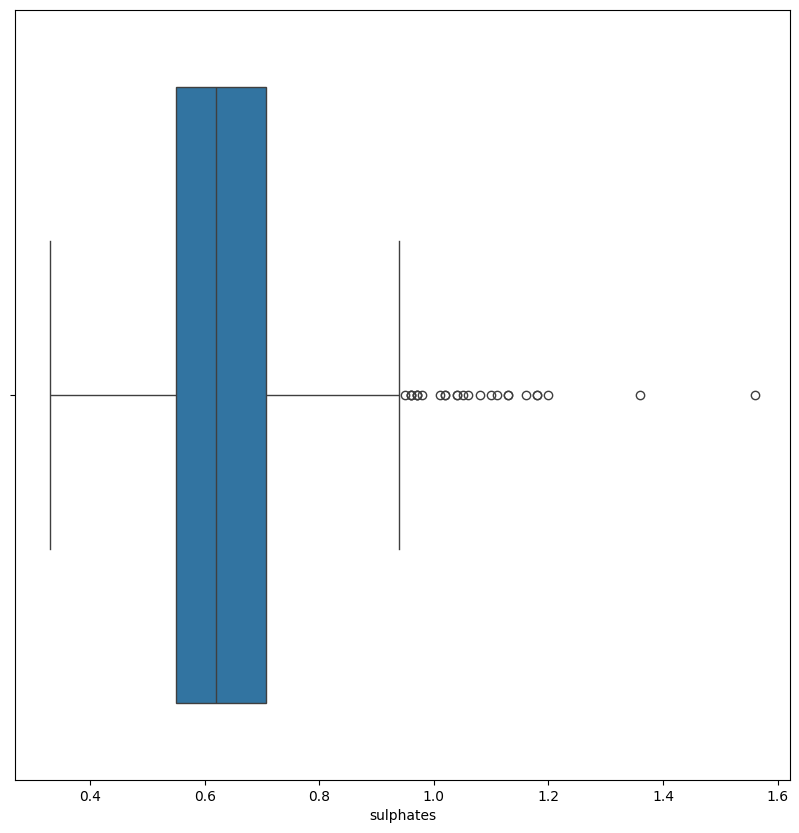

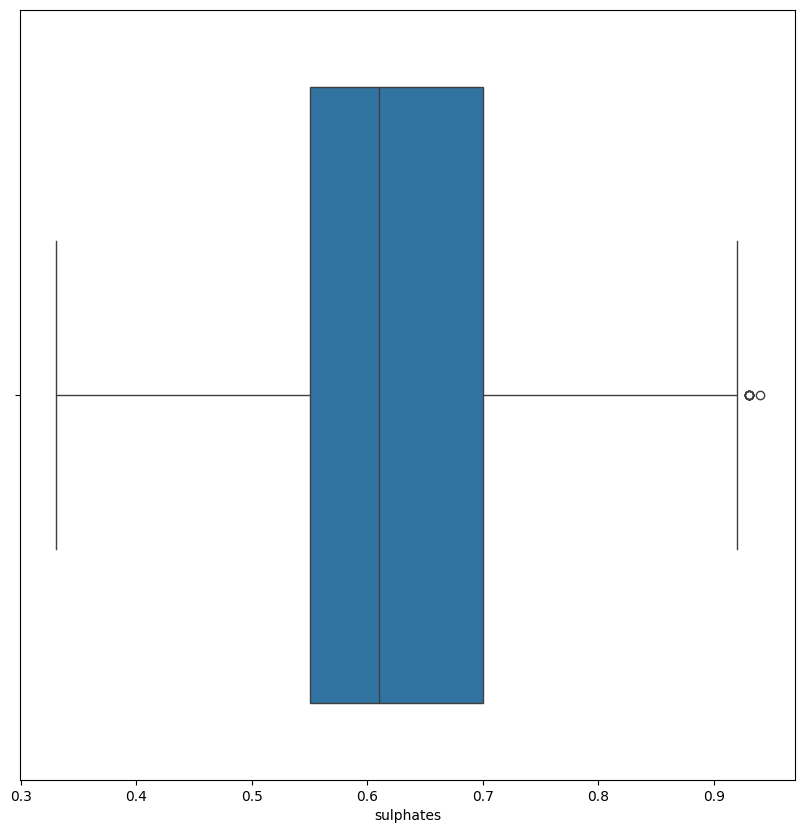

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data8['sulphates'],ax=ax)
q1=new_data8['sulphates'].quantile(0.25)
q3=new_data8['sulphates'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data9=new_data8[(new_data8['sulphates']>lower_bound)&(new_data8['sulphates']<upper_bound)]
print(new_data9)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data9['sulphates'],ax=ax)


      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

<Axes: xlabel='alcohol'>

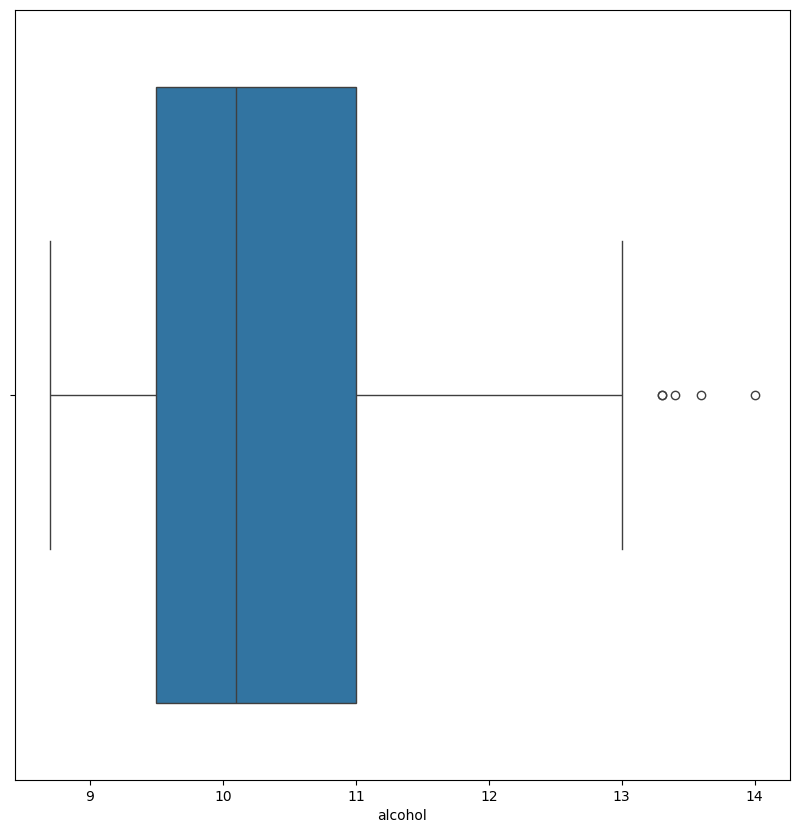

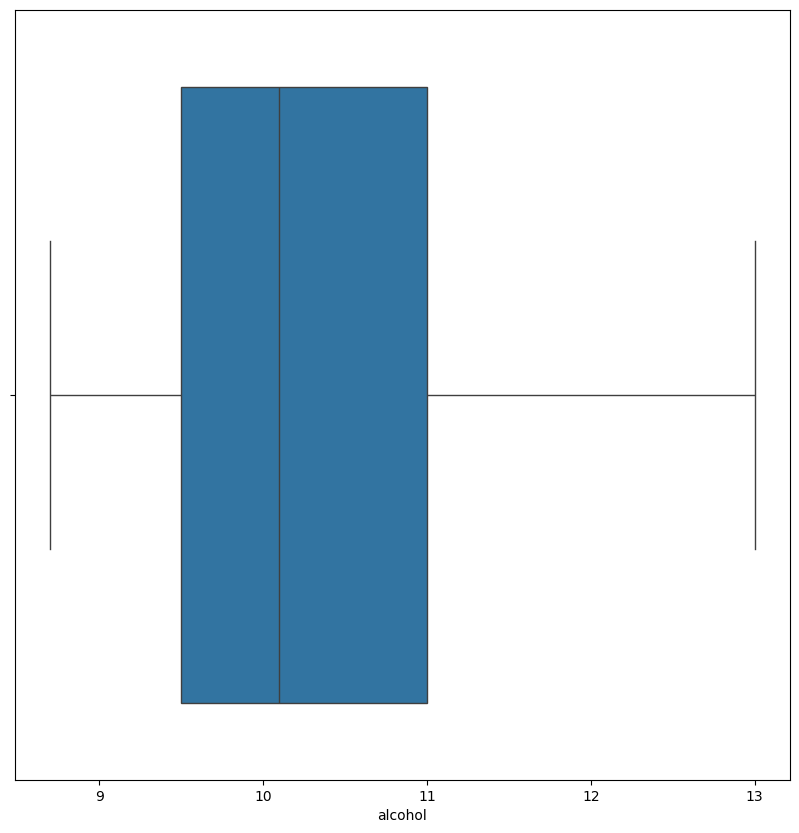

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=new_data9['alcohol'],ax=ax)
q1=new_data9['alcohol'].quantile(0.25)
q3=new_data9['alcohol'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
clean_data=new_data9[(new_data9['alcohol']>lower_bound)&(new_data9['alcohol']<upper_bound)]
print(clean_data)
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=clean_data['alcohol'],ax=ax)

<Axes: >

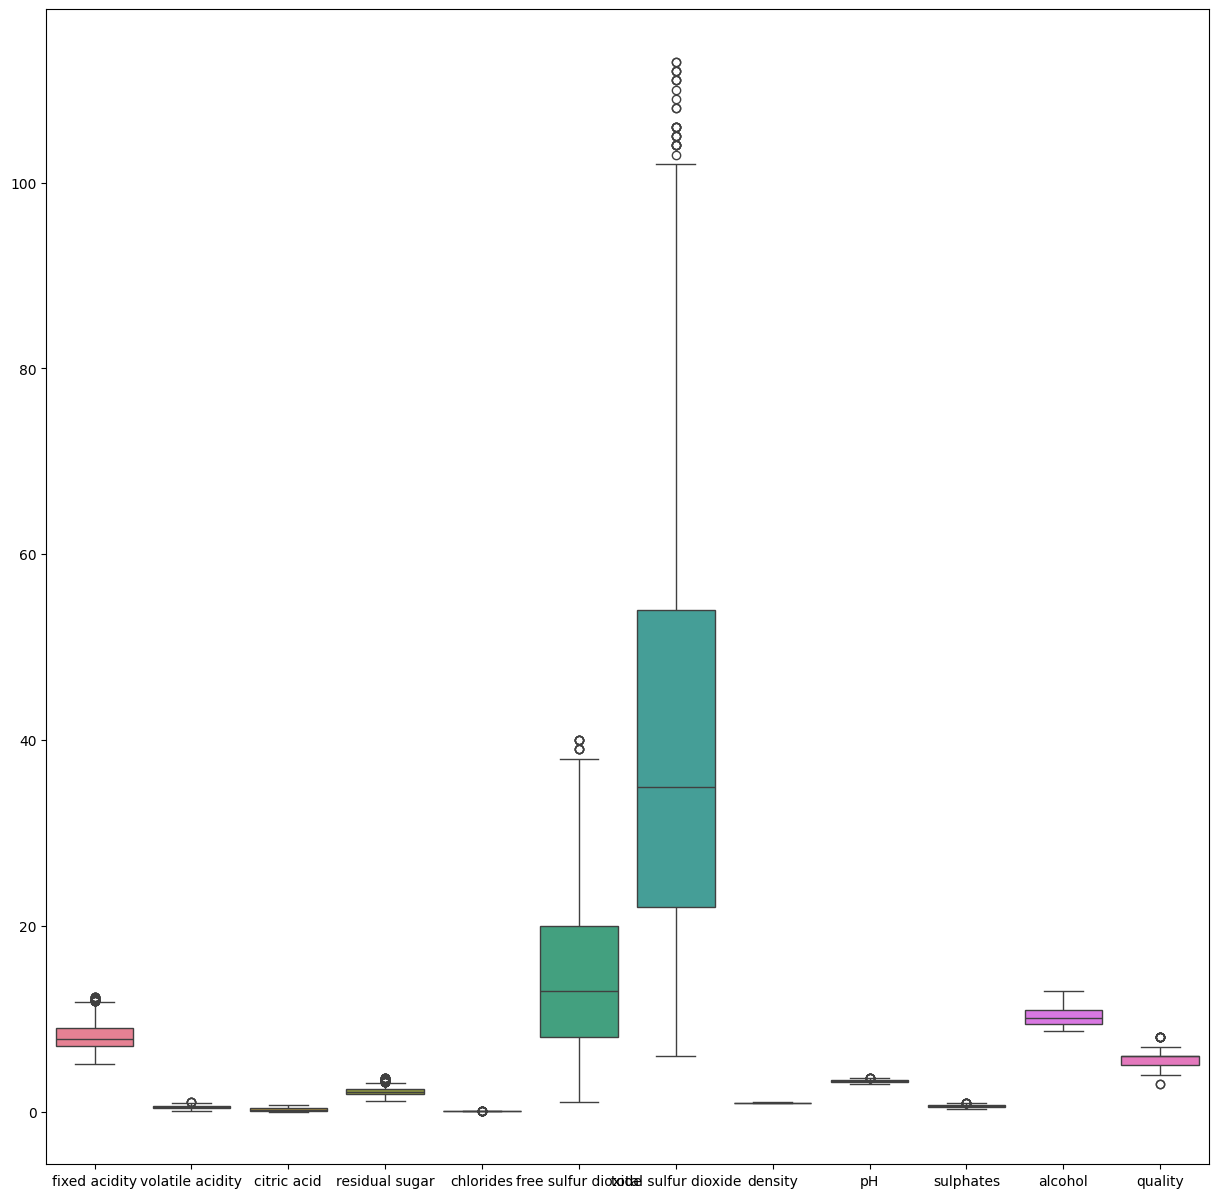

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=clean_data,ax=ax)

In [ ]:
correlation=clean_data.corr()
correlation

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.269133,0.659201,0.226868,0.168894,-0.168601,-0.091282,0.597415,-0.692961,0.160282,-0.011738,0.130647
volatile acidity,-0.269133,1.000000,-0.633684,0.028325,0.120929,-0.002098,0.091410,0.059705,0.224428,-0.337451,-0.247386,-0.365390
citric acid,0.659201,-0.633684,1.000000,0.151078,0.063009,-0.095014,-0.014289,0.291809,-0.475585,0.264897,0.168657,0.239435
residual sugar,0.226868,0.028325,0.151078,1.000000,0.235123,0.081341,0.175609,0.388476,-0.043130,0.048965,0.126587,0.041729
chlorides,0.168894,0.120929,0.063009,0.235123,1.000000,0.014543,0.192909,0.395286,-0.151296,-0.095866,-0.285840,-0.178778
free sulfur dioxide,-0.168601,-0.002098,-0.095014,0.081341,0.014543,1.000000,0.635157,-0.027314,0.160725,0.116513,-0.011702,-0.003130
total sulfur dioxide,-0.091282,0.091410,-0.014289,0.175609,0.192909,0.635157,1.000000,0.160564,0.032302,-0.057296,-0.247777,-0.189932
density,0.597415,0.059705,0.291809,0.388476,0.395286,-0.027314,0.160564,1.000000,-0.217487,0.054299,-0.527837,-0.206228
pH,-0.692961,0.224428,-0.475585,-0.043130,-0.151296,0.160725,0.032302,-0.217487,1.000000,-0.006881,0.097760,-0.088971
sulphates,0.160282,-0.337451,0.264897,0.048965,-0.095866,0.116513,-0.057296,0.054299,-0.006881,1.000000,0.281237,0.434908


<Axes: >

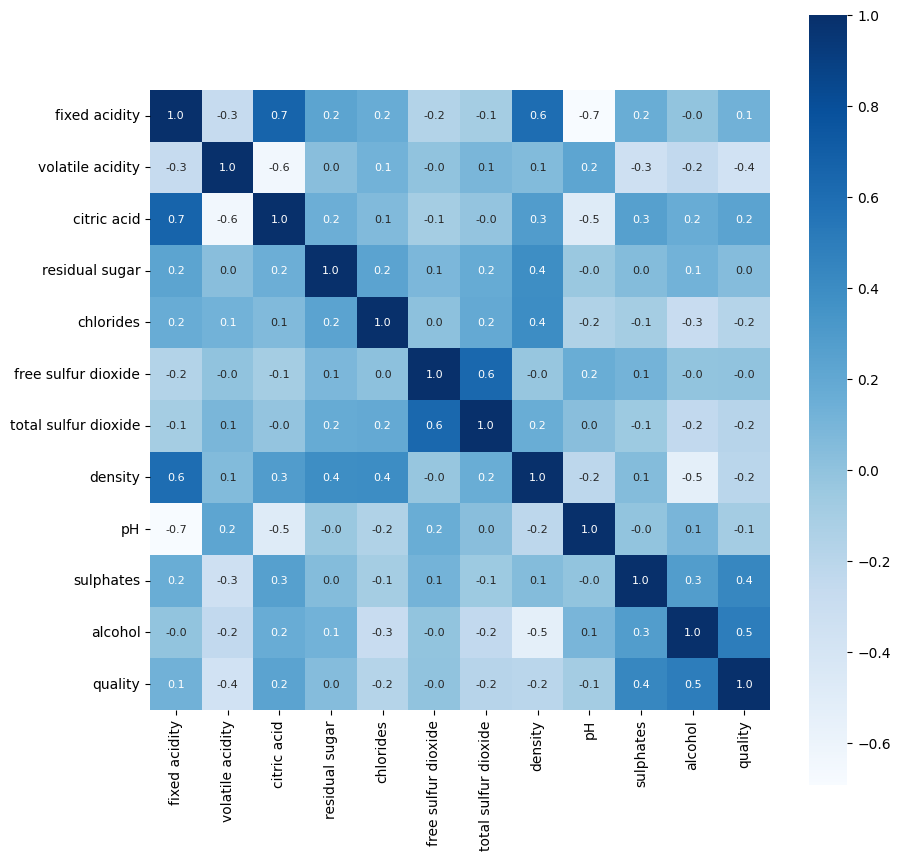

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [ ]:
clean_data['quality'].value_counts()

,count
quality,
5,490
6,472
7,130
4,32
8,9
3,2


In [ ]:
x = clean_data.drop(columns='quality', axis=1)
y = clean_data['quality'].apply(lambda y_value: 1 if y_value >= 7 else 0)
print(x)
print(y)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_resampled,y_resampled=smote.fit_resample(x,y)
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.3,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape,y_resampled.shape,x_resampled.shape

((1394, 11), (598, 11), (1394,), (598,), (1992,), (1992, 11))

In [ ]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
training_data_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(training_data_prediction,y_train)
print(training_data_accuracy)
testing_data_prediction=model.predict(x_test)
testing_data_accuracy=accuracy_score(testing_data_prediction,y_test)
print(testing_data_accuracy)

1.0
0.9331103678929766


In [ ]:
cm=confusion_matrix(y_test,testing_data_prediction)
print(cm)
print(classification_report(y_test, testing_data_prediction))

[[275  28]
 [ 12 283]]
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       303
           1       0.91      0.96      0.93       295

    accuracy                           0.93       598
   macro avg       0.93      0.93      0.93       598
weighted avg       0.93      0.93      0.93       598



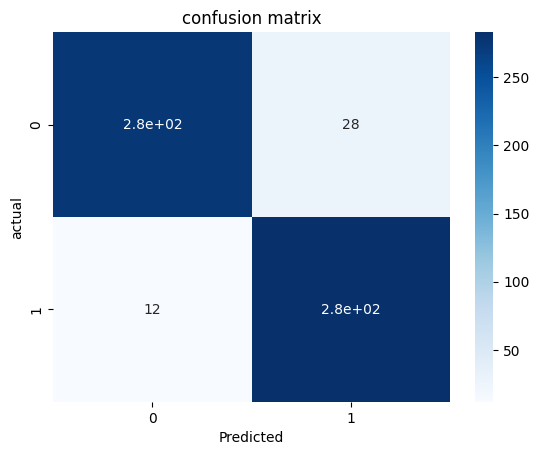

In [ ]:
sns.heatmap(cm,annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

In [ ]:
new_data = (6.8, 0.40, 0.35, 2.0, 0.060, 20.0, 50.0, 0.9950, 3.30, 0.75, 12.5)
new_data_as_numpy_array = np.asarray(new_data)
new_data_reshaped = new_data_as_numpy_array.reshape(1, -1)
prediction = model.predict(new_data_reshaped)
if prediction[0] == 0:
    print('The wine quality is bad')
else:
    print('The wine quality is good')

The wine quality is good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
